# Laboratorio 7 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

Link al repositorio: https://github.com/Its-Japo/VisionXComputadora 

# Task 1

## Pregunta 1.1


El médico coordinador del proyecto le presenta la siguiente situación: "Tenemos 800 radiografías
etiquetadas por nuestros radiólogos. Un colega me dijo que con tan pocos datos el modelo va a memorizar
todo y no va a servir para nada en producción."

Como ingeniero de IA a cargo, usted decide aplicar Data Augmentation como parte de la solución. Sin
embargo, el médico le pregunta: "¿No estamos inventando datos falsos que podrían confundir al modelo?"
Con esto en mente, responda las siguientes preguntas en su reporte:

1. Explíquele al médico, en términos que él pueda entender, qué es el Data Augmentation y por qué las
imágenes generadas no son datos falsos. Use la analogía que considere más apropiada.

R//

El Data Augmentation es una técnica para ampliar artificialmente el conjunto de entrenamiento aplicando transformaciones controladas a imágenes reales ya etiquetadas. La idea no es inventar pacientes ni patologías nuevas, sino presentar la misma evidencia clínica en variaciones plausibles que podrían ocurrir durante la adquisición de la imagen, como pequeños cambios de posición, escala o contraste. En tus diapositivas se describe justamente que el Data Augmentation aplica transformaciones T(x) a imágenes existentes para expandir el espacio de entrada y evitar que la red memorice píxeles específicos del dataset, mejorando así la generalización.

Una analogía útil para explicárselo al médico es la siguiente: es como si un residente aprendiera a reconocer una neumonía viendo la misma radiografía en diferentes condiciones de visualización: un poco más clara, un poco más oscura, ligeramente desplazada o con una pequeña variación de encuadre. La enfermedad no cambia; lo que cambia es la forma en que se presenta la imagen. Por eso, las imágenes aumentadas no son datos falsos, sino variantes válidas de datos reales, siempre que las transformaciones respeten la anatomía y no alteren el significado diagnóstico. El objetivo de este tipo de regularización es que el modelo aprenda patrones robustos y no dependa de detalles accidentales del set de entrenamiento.

En otras palabras, el modelo no debería aprender “esta radiografía exacta”, sino conceptos más generales como distribución de opacidades, tamaño cardíaco, patrón intersticial o consolidaciones. Esa es precisamente la lógica detrás de usar augmentación y otras técnicas de regularización para reducir sobreajuste.

2. En el contexto específico de radiografías de tórax, proponga tres transformaciones de Data
Augmentation que serían válidas y justifique cada una. Luego, identifique una transformación que
no debería aplicarse en este dominio médico y explique por qué podría comprometer la integridad
diagnóstica del modelo.
R//

Primero, pequeñas traslaciones o recortes leves.
Son válidos porque en la práctica clínica el encuadre nunca es idéntico: el paciente puede estar levemente centrado a la izquierda o derecha, o el campo radiográfico puede variar un poco entre estudios. Entrenar con estas variaciones ayuda a que el modelo no dependa de una posición exacta del pulmón dentro de la imagen y aprenda a reconocer hallazgos aunque cambie ligeramente la ubicación global. Esto es consistente con la idea de que el augmentation debe introducir invariancia útil sin alterar el contenido clínico.

Segundo, rotaciones pequeñas.
Una radiografía real puede presentar una inclinación leve por postura del paciente o por adquisición imperfecta. Permitir rotaciones pequeñas hace al modelo más tolerante a ese tipo de variación operativa. La clave es que sean pequeñas; no se trata de girar la placa de manera extrema, sino de simular desalineaciones realistas de adquisición.

Tercero, ajustes moderados de brillo o contraste.
En imagen médica puede haber diferencias de exposición, procesamiento digital o visualización entre equipos y centros. Una modificación moderada del contraste o intensidad puede ayudar a que el modelo reconozca el mismo patrón patológico bajo distintas condiciones de adquisición o posprocesamiento. Debe hacerse con prudencia, porque el propósito es simular variabilidad real del sistema, no deformar la apariencia de los hallazgos. Tus materiales del curso mencionan explícitamente modificaciones de brillo y contraste como formas comunes de augmentation.

Una transformación que no debería aplicarse en este dominio es el flip horizontal.
La razón es que en tórax la lateralidad importa clínicamente: invertir izquierda y derecha puede cambiar la interpretación anatómica, la localización de dispositivos, la posición cardíaca, la distribución de derrames o la referencia de lesiones unilaterales. Aunque la imagen siga “pareciendo” un tórax, su significado clínico ya no sería fiel al caso original. En este contexto sí se estaría comprometiendo la integridad diagnóstica del dato, porque la transformación altera información semántica importante para el diagnóstico. Por eso, no toda transformación geométrica válida en visión por computadora general es válida en imagen médica.

3. ¿Es el Data Augmentation suficiente por sí solo para garantizar que el modelo generalice bien?
Argumente su posición considerando otras variables del proceso de entrenamiento.

R//

No. El Data Augmentation ayuda mucho, pero no es suficiente por sí solo para garantizar que el modelo generalice bien. La generalización depende también de la calidad del dataset, del balance entre clases, de la separación correcta entre entrenamiento/validación/prueba, de la arquitectura elegida, de la regularización, del optimizador, del learning rate y, especialmente en este caso, del uso de transfer learning por tratarse de un conjunto pequeño de solo 800 estudios. Tus diapositivas del curso lo dejan claro: con pocos datos etiquetados, la estrategia robusta no es usar augmentation aislado, sino combinarlo con transferencia de aprendizaje, fine-tuning, Adam y técnicas de regularización como L2, dropout y early stopping.

Además, el sobreajuste no aparece solo por “tener pocos datos”, sino también porque el modelo puede aprender correlaciones espurias o detalles irrelevantes del conjunto de entrenamiento. La literatura de visión y deep learning insiste en que regularización y validación son necesarias para evitar que el modelo ajuste ruido o peculiaridades del dataset en vez de aprender patrones verdaderos.

En este proyecto, el argumento más sólido sería decir que el Data Augmentation es una pieza de la solución, no la solución completa. Con 800 radiografías, una estrategia razonable sería partir de un modelo preentrenado, congelar o reutilizar capas tempranas que ya capturan bordes, texturas y estructuras visuales generales, y luego hacer fine-tuning cuidadoso sobre el dominio médico. Ese es justamente el valor del transfer learning cuando el conjunto etiquetado es limitado: reduce requerimientos de datos, acelera el entrenamiento y suele mejorar la capacidad de generalización frente a entrenar desde cero.

Por tanto, mi posición es la siguiente: el Data Augmentation es necesario y útil, pero no garantiza por sí solo una buena generalización. Para que el modelo sea confiable en producción también se necesita un buen diseño experimental, validación externa si es posible, control del sobreajuste, regularización adecuada y transferencia de aprendizaje adaptada al dominio de radiografías.

## Pregunta 1.2

Durante el entrenamiento del modelo de MediScan Guatemala, el equipo registra las siguientes curvas de
pérdida (loss) al finalizar 25 épocas:

Con base a estos datos, responda dentro de su reporte:

4. Identifique a partir de qué época aproximada comienza el sobreajuste (overfitting) y describa cómo
se evidencia en los números de la tabla.

R//

El sobreajuste comienza aproximadamente a partir de la época 10 y se vuelve claro en la 15. Hasta la época 10, tanto la pérdida de entrenamiento como la de validación disminuyen, lo que indica aprendizaje útil. Sin embargo, desde la época 15, la pérdida de entrenamiento sigue bajando de 0.31 a 0.18, 0.09 y 0.04, mientras la pérdida de validación sube de 0.38 a 0.42, 0.61 y 0.89. Ese patrón muestra que el modelo está mejorando solo sobre los datos que ya vio, pero empeorando en datos nuevos, que es precisamente la señal clásica de sobreajuste. La regularización y el early stopping se presentan en clase justamente como mecanismos para evitar este comportamiento.

5. Proponga dos estrategias de regularización concretas (por ejemplo, Dropout o L2) que podría haber
implementado para prevenir este comportamiento. Para cada una, explique intuitivamente qué
fenómeno matemático está mitigando y qué impacto esperaría ver en las curvas de la tabla.

R//

Una primera estrategia es Dropout. Esta técnica apaga neuronas aleatoriamente durante el entrenamiento, lo que evita que la red dependa demasiado de combinaciones muy específicas de activaciones. Intuitivamente, mitiga la coadaptación excesiva entre neuronas y obliga al modelo a distribuir mejor la información. En las curvas, esperaría ver que el loss de entrenamiento bajara más lentamente, pero que el loss de validación dejara de crecer tan pronto o incluso se mantuviera más estable.

Una segunda estrategia es la regularización L2. Esta añade una penalización a los pesos grandes en la función de pérdida, lo que matemáticamente empuja al modelo a encontrar soluciones más simples y menos extremas. Intuitivamente, reduce la tendencia a ajustar ruido o detalles accidentales del conjunto de entrenamiento. En la tabla, esperaría una caída menos agresiva del loss de entrenamiento, pero también una separación menor entre entrenamiento y validación, con una curva de validación más contenida.

6. Desde una perspectiva médica, ¿por qué es especialmente peligroso desplegar en producción un
modelo que exhibe este patrón de sobreajuste para el diagnóstico de radiografías? Argumente más
allá de los números.

R//

Es especialmente peligroso porque un modelo sobreajustado puede parecer excelente en desarrollo, pero fallar cuando enfrenta radiografías reales de otros hospitales, equipos, protocolos de adquisición o perfiles de pacientes. En medicina, eso significa que el sistema podría aprender señales irrelevantes del dataset, como contrastes particulares, artefactos o patrones del proceso de captura, en lugar de aprender hallazgos radiológicos verdaderamente asociados a neumonía. El riesgo clínico no es solo “bajar precisión”, sino producir falsos negativos que dejen a un paciente sin tratamiento oportuno, o falsos positivos que generen ansiedad, antibióticos innecesarios, estudios adicionales y sobrecarga del sistema. En un contexto médico, un modelo debe generalizar de forma robusta, porque las decisiones impactan directamente la seguridad del paciente y la confianza del personal clínico. La motivación de usar regularización, augmentación y transferencia de aprendizaje en datasets pequeños es precisamente mejorar esa capacidad de generalización.

## Pregunta 1.3

Un inversionista que asiste a la demo del proyecto le pregunta: "¿Por qué su modelo tiene un 94% de
accuracy en las pruebas? ¿Eso significa que es confiable para diagnosticar neumonía?"
Usted sabe que el dataset de prueba contiene 700 radiografías normales y solo 150 radiografías con
neumonía.

Responda lo siguiente en su reporte:

7. Calcule cuál sería el accuracy de un modelo naive que simplemente predice siempre 'Normal' para
todas las imágenes. ¿Qué revela ese cálculo sobre el 94% reportado?

R//

Si el conjunto de prueba tiene 700 radiografías normales y 150 con neumonía, entonces hay 850 imágenes en total. Un modelo naive que siempre predice “Normal” acertaría las 700 normales y fallaría las 150 neumonías.

Accuracy = 700/850 = 0.8235 ≈ 82.35%

Esto revela que el 94% de accuracy, aunque mayor, no es suficiente por sí solo para concluir que el modelo es confiable. El dataset está desbalanceado, así que una métrica global como accuracy puede verse inflada por la clase mayoritaria. La diferencia entre 82.35% y 94% sugiere mejora, pero no demuestra por sí misma que el sistema detecte bien la neumonía, que es justamente la clase clínica más importante.

8. Explique por qué, en problemas médicos con clases desbalanceadas, métricas como el F1-Score o
la Sensibilidad (Recall) para la clase minoritaria son más informativas que el accuracy. No se limite
a definirlas; argumente su relevancia clínica.

R//

En problemas médicos con clases desbalanceadas, el accuracy puede ocultar fallas graves porque está dominado por la clase más frecuente. Si la mayoría de estudios son normales, un modelo puede obtener un accuracy alto aunque detecte mal los casos enfermos. En cambio, la Sensibilidad (Recall) para la clase minoritaria mide cuántos pacientes realmente enfermos fueron identificados, lo cual tiene relevancia clínica directa: una sensibilidad baja implica neumonías no detectadas y, por tanto, retraso en diagnóstico y tratamiento.

El F1-Score también es útil porque equilibra sensibilidad y precisión; no solo importa encontrar enfermos, sino evitar marcar como neumonía demasiados casos normales. Clínicamente, estas métricas reflejan mejor el costo real de los errores: perder un paciente enfermo suele ser mucho más grave que clasificar de más algunos casos sospechosos. Por eso, en un sistema de apoyo diagnóstico, importa más saber qué tan bien identifica la condición crítica que quedarse únicamente con un porcentaje global de aciertos.

9. Como director técnico, ¿cómo le respondería al inversionista de forma honesta y profesional?
Redacte una respuesta breve (3 a 5 oraciones) que sea técnicamente sólida pero comprensible para
un no-especialista.

R//

El 94% de accuracy es un resultado prometedor, pero por sí solo no garantiza que el modelo sea confiable para diagnosticar neumonía. Nuestro conjunto de prueba está desbalanceado, así que necesitamos revisar métricas más importantes clínicamente, como cuántos casos de neumonía detecta correctamente y cuántos se le escapan. En salud, un error sobre un paciente enfermo tiene mucho más peso que un acierto sobre un caso normal. Por eso, antes de hablar de despliegue clínico, debemos validar sensibilidad, F1-score y desempeño en datos externos reales.

# Task 2

Las siguientes preguntas evalúan la comprensión **conceptual y estratégica** del Transfer Learning y el Fine-Tuning, siempre enmarcadas en el contexto de MediScan Guatemala.

## Pregunta 2.1

Un desarrollador del equipo propone: *"Para el modelo de radiografías no tiene sentido usar Transfer Learning desde ImageNet; ese dataset tiene fotos de perros, gatos y autos. Las radiografías son imágenes en escala de grises totalmente distintas. Mejor entrenamos desde cero para no contaminar el modelo."*

**1. ¿Está de acuerdo con el desarrollador? Argumente su posición con base en lo que las capas convolucionales tempranas de una CNN realmente aprenden y por qué ese conocimiento sí es transferible, incluso entre dominios visualmente distintos.**

R//

No estoy de acuerdo con el desarrollador. Su razonamiento parece intuitivo a primera vista, pero ignora un hallazgo fundamental y ampliamente documentado en la investigación de deep learning: las capas tempranas de una CNN no aprenden a reconocer "perros" ni "autos", sino que aprenden representaciones visuales de bajo nivel que son universales y completamente agnósticas al dominio de origen. Concretamente, las primeras capas detectan bordes, gradientes de intensidad, texturas locales, esquinas y patrones de frecuencia espacial. Estos elementos son los bloques constructivos básicos de cualquier imagen, independientemente de si es una fotografía a color de un animal o una radiografía en escala de grises de un tórax.

Este comportamiento fue demostrado de forma rigurosa por Zeiler y Fergus (2014) mediante la visualización de las activaciones capa por capa de una CNN entrenada en ImageNet. Sus resultados muestran que las capas 1 y 2 responden a bordes orientados y texturas simples, las capas intermedias combinan esos primitivos en patrones más complejos como contornos, formas geométricas y estructuras repetitivas, y solamente las capas profundas finales se especializan en representaciones semánticas concretas del dominio de entrenamiento original. Lo crucial es que las capas tempranas, que son precisamente las más transferibles, codifican conocimiento visual genérico que cualquier tarea de visión por computadora necesita.

En el caso específico de radiografías de tórax, el modelo necesita detectar bordes de estructuras anatómicas como costillas, silueta cardíaca y contornos pulmonares; necesita identificar texturas del parénquima pulmonar; necesita reconocer variaciones de intensidad que indican consolidaciones, opacidades o derrames; y necesita captar transiciones entre regiones de diferente densidad radiológica. Todas estas capacidades se construyen sobre exactamente los mismos filtros de bajo nivel que una red ya aprendió con ImageNet. Reutilizar esas capas no "contamina" el modelo, al contrario: le proporciona una base sólida y bien calibrada desde la cual adaptarse al dominio médico con muchos menos datos y con menor riesgo de sobreajuste.

En cuanto al argumento de que las radiografías son en escala de grises mientras que ImageNet contiene imágenes a color: esto es un detalle técnico menor que se resuelve fácilmente, no un impedimento conceptual. En la práctica, basta con replicar el canal de grises en tres canales para alimentar la red, o incluso se puede modificar únicamente la primera capa convolucional y transferir todo el resto de la arquitectura. La diferencia de dominio visual entre ImageNet y radiografías no invalida la transferencia; simplemente implica que las capas más profundas necesitarán más adaptación mediante fine-tuning, mientras que las capas tempranas seguirán siendo útiles prácticamente tal como están.

En conclusión, el transfer learning desde ImageNet no solo tiene sentido para radiografías, sino que es la estrategia recomendada cuando se dispone de un dataset pequeño como las 800 imágenes de MediScan Guatemala. Entrenar desde cero desperdiciaría todo el conocimiento visual de bajo nivel ya aprendido y aumentaría significativamente el riesgo de sobreajuste, dado que la red tendría que descubrir por sí misma representaciones que ya están disponibles en los pesos preentrenados.

**2. Más allá del argumento técnico, ¿cuál es el costo real de entrenar desde cero para una startup como MediScan Guatemala? Considere al menos dos dimensiones distintas a la puramente computacional (p. ej., tiempo al mercado, riesgo, talento humano).**

R//

Entrenar un modelo desde cero tiene costos que van mucho más allá del gasto en GPUs o del tiempo de cómputo. Para una startup como MediScan Guatemala, que opera en un mercado de salud con recursos limitados y con una urgencia real de generar impacto clínico, estos costos ocultos pueden ser determinantes para la viabilidad misma del proyecto.

**Primera dimensión: tiempo al mercado (time-to-market).** Entrenar desde cero requiere muchas más épocas de experimentación, ciclos prolongados de ajuste de hiperparámetros, prueba-error en el diseño de la arquitectura, y múltiples iteraciones antes de alcanzar un rendimiento aceptable. Todo esto retrasa considerablemente el momento en que el producto puede entrar en operación real en hospitales o clínicas. En el contexto de salud pública en Guatemala, cada mes de retraso puede traducirse en pacientes que no reciben un apoyo diagnóstico que podría haber estado disponible antes. Además, una startup que tarda demasiado en demostrar resultados tangibles pierde credibilidad frente a inversionistas, aliados institucionales y el propio sistema de salud que espera soluciones concretas.

**Segunda dimensión: riesgo técnico y necesidad de talento altamente especializado.** Diseñar y entrenar una arquitectura de red neuronal desde cero exige un equipo con experiencia profunda en diseño de arquitecturas, estrategias de inicialización de pesos, selección de funciones de activación, debugging de problemas de convergencia y estabilidad del entrenamiento. Ese nivel de talento en deep learning es escaso y costoso en cualquier parte del mundo, pero especialmente en el ecosistema tecnológico centroamericano. Con transfer learning, el equipo técnico puede concentrar sus esfuerzos en el fine-tuning y, sobre todo, en la validación clínica del modelo, que es donde realmente se genera valor diferencial para el producto. Además, entrenar desde cero con solo 800 imágenes conlleva un riesgo alto de producir un modelo que no generalice adecuadamente, lo que podría obligar a reiniciar el desarrollo desde el principio y generar costos hundidos que una startup difícilmente puede absorber.

En síntesis, para MediScan Guatemala la decisión de entrenar desde cero no solo sería técnicamente subóptima sino estratégicamente costosa: más tiempo para llegar al mercado, mayor dependencia de talento escaso y caro, y un riesgo significativamente mayor de fracaso técnico con un dataset tan limitado.

**3. ¿Existe algún escenario legítimo en que usted sí consideraría entrenar desde cero en lugar de hacer Transfer Learning? Descríbalo y justifíquelo.**

R//

Sí, existen escenarios legítimos donde entrenar desde cero podría ser la mejor opción, aunque ninguno de ellos corresponde al caso actual de MediScan Guatemala.

El escenario más claro es cuando se dispone de un dataset muy grande en el dominio objetivo y, simultáneamente, la naturaleza de las imágenes es radicalmente diferente de las fotografías naturales de ImageNet. Por ejemplo, si tuviéramos acceso a cientos de miles o millones de imágenes médicas especializadas, como cortes histopatológicos de alta resolución, imágenes de microscopía electrónica, o volúmenes 3D de resonancia magnética, y además la estructura visual de esas imágenes fuera tan distinta que los filtros aprendidos en ImageNet no ofrecieran ventaja significativa ni siquiera en las primeras capas, entonces entrenar desde cero podría igualar o incluso superar al transfer learning. En ese caso, la abundancia de datos compensa la pérdida de la inicialización preentrenada y permite que la red descubra representaciones verdaderamente óptimas para el dominio específico.

Otro escenario válido sería cuando el problema exige una arquitectura fundamentalmente diferente a las disponibles con pesos preentrenados. Si la tarea requiere una red con entrada multicanal (por ejemplo, imágenes multiespectrales con 7 o más bandas), con dimensiones espaciales no estándar, o con módulos especializados que no tienen equivalente en las arquitecturas clásicas entrenadas sobre ImageNet, entonces simplemente no hay pesos preentrenados que transferir de manera significativa, y entrenar desde cero se convierte en la opción natural y necesaria.

Un tercer escenario, menos frecuente pero relevante, es cuando existen restricciones regulatorias o de propiedad intelectual que impiden usar modelos preentrenados en ciertos contextos comerciales o clínicos, obligando a desarrollar todo el pipeline de entrenamiento internamente.

Sin embargo, para MediScan Guatemala ninguno de estos escenarios aplica: tenemos solo 800 imágenes, usamos radiografías 2D convencionales que comparten primitivos visuales con ImageNet, y las arquitecturas estándar (ResNet, VGG, EfficientNet) con pesos preentrenados están disponibles libremente y son adecuadas para el problema. Por lo tanto, en este contexto concreto, el transfer learning es indiscutiblemente la mejor estrategia.

---

## Pregunta 2.2

Su equipo debe decidir la estrategia de Fine-Tuning para el modelo de MediScan Guatemala. El CTO les propone dos opciones:

| Opción | A — Congelar toda la red base | B — Descongelar toda la red |
|--------|-------------------------------|------------------------------|
| Capas base | Congeladas (gradiente = 0) | Todas entrenables |
| Tasa de aprendizaje | Alta (1e-3) | Muy baja (1e-5) en toda la red |
| Cabezal final | Entrenado desde cero | Entrenado con tasa 1e-3 |

**4. Dada la naturaleza del dataset médico disponible (800 imágenes, dominio distinto a ImageNet), ¿cuál opción recomendaría y por qué? No se limite a decir cuál es la regla de oro; explique la lógica detrás de esa regla en este caso concreto.**

R//

Recomendaría la **Opción A** como punto de partida: congelar toda la red base y entrenar únicamente el cabezal de clasificación con una tasa de aprendizaje alta (1e-3).

La lógica detrás de esta recomendación se fundamenta en la llamada "regla de oro" del fine-tuning, que establece que cuanto menor sea el dataset disponible y mayor la diferencia respecto al dominio de preentrenamiento, más conservador debe ser el ajuste de los pesos. Pero más allá de repetir la regla, es importante entender por qué aplica con tanta fuerza en este caso concreto.

Con solo 800 imágenes, el riesgo dominante es el sobreajuste. Si descongelamos toda la red (Opción B), estamos exponiendo millones de parámetros a ser actualizados por un conjunto de datos extremadamente pequeño en proporción. Incluso con una tasa de aprendizaje baja como 1e-5, la cantidad de parámetros entrenables es desproporcionada respecto a la cantidad de ejemplos disponibles, lo que facilita que la red memorice particularidades del set de entrenamiento en vez de aprender patrones genuinamente generalizables. Es un problema de ratio: si tienes millones de parámetros ajustables y solo cientos de ejemplos, los grados de libertad del modelo superan enormemente la información contenida en los datos.

Al congelar las capas base (Opción A), aprovechamos intactas todas las representaciones visuales de bajo y medio nivel que la red aprendió con ImageNet, bordes, texturas, gradientes, formas geométricas, sin ningún riesgo de destruirlas o degradarlas. Solo entrenamos el cabezal final, que es la parte que necesita adaptarse específicamente al nuevo problema de clasificación (neumonía vs. normal). Este cabezal tiene muchos menos parámetros, por lo que 800 imágenes resultan mucho más razonables para ajustarlo sin caer en sobreajuste severo.

La tasa de aprendizaje alta (1e-3) para el cabezal tiene pleno sentido porque esos pesos parten de una inicialización aleatoria y necesitan moverse rápidamente hacia una configuración útil. En contraste, las capas base ya poseen pesos bien calibrados por el preentrenamiento; moverlos agresivamente, o siquiera moverlos con tan pocos datos, podría destruir la representación aprendida que es precisamente lo que queremos conservar.

Dicho esto, una estrategia todavía más refinada sería empezar con la Opción A para entrenar el cabezal hasta convergencia, y luego hacer un segundo paso donde se descongelen selectivamente solo las últimas capas de la red base con una tasa de aprendizaje muy reducida, lo que se conoce como fine-tuning gradual o progresivo. Pero como punto de partida con apenas 800 imágenes, congelar todo y entrenar solo el cabezal es la decisión más segura, más fundamentada y más difícil de que salga mal.

**5. ¿Qué riesgo específico correría si aplica la Opción B con una tasa de aprendizaje alta (p. ej., 1e-3) en toda la red? ¿Cómo se llama ese fenómeno y cómo se evidenciaría durante el entrenamiento?**

R//

Si se aplica la Opción B con una tasa de aprendizaje alta (1e-3) en toda la red, el riesgo principal es lo que se conoce como **catastrophic forgetting** (olvido catastrófico). Este fenómeno ocurre cuando los gradientes generados por el nuevo dataset son lo suficientemente grandes como para sobrescribir de forma destructiva los pesos que la red había aprendido cuidadosamente durante el preentrenamiento con millones de imágenes de ImageNet.

Lo que sucede desde el punto de vista matemático es directo: con una tasa de aprendizaje alta, las actualizaciones de los pesos en cada paso de entrenamiento son grandes (Δw = −η · ∂L/∂w, donde η = 1e-3 produce actualizaciones considerables). Esto significa que en pocas iteraciones los filtros de las capas tempranas, que originalmente detectaban bordes universales, texturas genéricas y patrones de frecuencia útiles para cualquier tarea visual, se deforman rápidamente para ajustarse a las peculiaridades específicas de solo 800 imágenes. El resultado es doblemente negativo: la red pierde su capacidad de representación general que había adquirido con ImageNet, pero tampoco logra aprender una buena representación específica del nuevo dominio médico, porque los datos son absolutamente insuficientes para recalibrar millones de parámetros de forma estable y significativa.

Durante el entrenamiento, este fenómeno se evidenciaría de varias formas observables. En las primeras épocas se podría ver una caída brusca del loss de entrenamiento, ya que la red ajusta rápidamente sus pesos a los pocos datos disponibles, pero simultáneamente el loss de validación se estancaría o incluso comenzaría a aumentar desde etapas muy tempranas. También podría observarse inestabilidad marcada en las curvas: el loss de entrenamiento oscila de manera errática entre épocas, o el accuracy de validación fluctúa sin mostrar una tendencia clara de mejora sostenida. En los casos más severos, el modelo puede colapsar completamente, prediciendo siempre la misma clase para todas las imágenes o produciendo probabilidades prácticamente uniformes entre clases, lo que demuestra que ha perdido toda capacidad discriminativa.

Una analogía útil: usar una tasa de aprendizaje alta en toda la red con pocos datos es como intentar recalibrar un instrumento de precisión ya ajustado usando un martillo. Se destruye la calibración fina que ya existía sin lograr una nueva calibración estable, quedando en un estado peor que antes del intento.

**6. Si con el tiempo MediScan Guatemala logra recolectar 50,000 radiografías etiquetadas, ¿cambiaría su recomendación? Explique cómo evolucionaría su estrategia de Fine-Tuning y por qué.**

R//

Sí, con 50,000 radiografías etiquetadas la recomendación cambiaría de forma significativa. Con un dataset de ese tamaño, ya no estamos en el escenario de "datos escasos" donde el temor principal es el sobreajuste; ahora disponemos de suficientes ejemplos para ajustar más parámetros de la red de manera estable y con señal estadística real.

La estrategia evolucionaría hacia un fine-tuning progresivo considerablemente más agresivo, que se puede describir en etapas:

**Primera etapa:** igual que antes, entrenar el cabezal de clasificación con las capas base completamente congeladas. Esto sigue siendo una buena práctica de inicialización para que el cabezal aprenda a mapear las representaciones existentes al problema de neumonía antes de perturbar nada en la red base.

**Segunda etapa:** descongelar las capas superiores de la red base (por ejemplo, los últimos dos o tres bloques residuales en una ResNet) y continuar el entrenamiento con una tasa de aprendizaje moderadamente baja (por ejemplo, 1e-4). Con 50,000 imágenes hay datos suficientes para que estas capas se adapten al dominio específico de radiografías sin riesgo significativo de destruir las representaciones aprendidas. Las capas superiores son precisamente las que más se benefician de esta adaptación, porque codifican patrones de nivel medio-alto que sí difieren sustancialmente entre fotografías naturales y estudios radiológicos.

**Tercera etapa (opcional):** si los resultados de validación lo justifican, se podría descongelar toda la red con una tasa de aprendizaje muy baja (1e-5) para hacer un ajuste fino global. Con 50,000 ejemplos, el riesgo de catastrophic forgetting se reduce considerablemente porque los gradientes se promedian sobre muchos más ejemplos y las actualizaciones resultantes son más representativas de la distribución real del dominio médico.

La razón fundamental de este cambio de estrategia es que la regla de oro del fine-tuning no es una regla estática e inmutable: depende del balance entre la cantidad de datos disponibles y la cantidad de parámetros que se desean ajustar. Con 800 imágenes, el ratio datos/parámetros era extremadamente desfavorable para descongelar cualquier parte de la red. Con 50,000, ese ratio mejora drásticamente, y descongelar capas permite que el modelo desarrolle representaciones verdaderamente especializadas para el dominio médico que pueden superar a las representaciones genéricas heredadas de ImageNet. Incluso podría considerarse explorar arquitecturas más grandes o un entrenamiento end-to-end completo si la ganancia marginal en métricas clínicas lo justifica.

---

## Pregunta 2.3

El área de Producto de MediScan Guatemala les presenta el siguiente requerimiento: *"El hospital nos pide expandir el sistema para que también detecte fracturas en radiografías de muñeca, usando el mismo modelo que ya tenemos para neumonía. ¿Podemos reutilizarlo directamente o hay que empezar todo de nuevo?"*

**7. Evalúe la viabilidad de reutilizar el modelo de neumonía para el nuevo problema de fracturas en muñeca. ¿Qué partes del modelo podrían aprovecharse y cuáles habría que modificar? Argumente con base en lo que cada sección de la red ha aprendido.**

R//

Es viable reutilizar parcialmente el modelo de neumonía, pero definitivamente no de forma directa. No se puede tomar el modelo entrenado para tórax tal como está y aplicarlo a radiografías de muñeca esperando que funcione, porque el cabezal de clasificación fue entrenado específicamente para distinguir "neumonía vs. normal" en imágenes de tórax, y las últimas capas convolucionales se adaptaron a patrones visuales propios del parénquima pulmonar. Sin embargo, una parte significativa del modelo sí es reutilizable, y eso representa una ventaja importante frente a empezar completamente de cero.

**Capas tempranas y medias (reutilizables).** Las capas iniciales e intermedias de la red, que originalmente provienen del preentrenamiento en ImageNet y que fueron congeladas o mínimamente ajustadas durante el fine-tuning para neumonía, siguen conteniendo detectores de bordes, texturas óseas, gradientes de intensidad y formas geométricas que son universales en imagen médica radiológica. Estos filtros son igualmente útiles para detectar líneas de fractura, discontinuidades en la corteza ósea o alteraciones en la densidad del hueso en una radiografía de muñeca. La razón es que tanto las radiografías de tórax como las de muñeca comparten el mismo principio físico de adquisición (rayos X) y, por tanto, tienen propiedades visuales de bajo nivel muy similares: son imágenes en escala de grises donde las diferencias de densidad tisular se manifiestan como variaciones de intensidad.

**Capas superiores (requieren re-entrenamiento).** Durante el fine-tuning para neumonía, las capas más profundas de la red base se adaptaron para reconocer patrones como consolidaciones pulmonares, opacidades difusas, derrames pleurales y la morfología general del tórax. Estos patrones de alto nivel no son directamente transferibles a fracturas de muñeca, donde lo clínicamente relevante es la anatomía ósea del carpo, radio y cúbito distal, y específicamente las discontinuidades sutiles en la corteza ósea que indican fractura. Estas capas necesitarían ser re-entrenadas para adaptarse al nuevo dominio anatómico.

**Cabezal de clasificación (debe reemplazarse completamente).** El cabezal fue diseñado para un problema binario específico (neumonía vs. normal en tórax) y sus pesos no tienen ninguna relevancia para el nuevo problema. Se necesita un cabezal nuevo, diseñado y entrenado desde cero para la tarea de clasificación de fracturas en muñeca.

En resumen: las capas base tempranas se aprovechan directamente (conocimiento visual genérico compartido entre modalidades radiológicas), las capas superiores requieren fine-tuning significativo (adaptación de dominio anatómico), y el cabezal se reemplaza por completo. Esto no es "empezar de cero" — es aplicar transfer learning a una segunda tarea médica, y resulta más eficiente y seguro que entrenar una red nueva desde una inicialización aleatoria.

**8. Proponga un plan de acción concreto de tres pasos para adaptar el modelo existente al nuevo dominio. Sea específico: ¿qué congela, qué descongela, qué modifica en el cabezal, qué tasa de aprendizaje usaría y por qué?**

R//

**Paso 1 — Reemplazar el cabezal y entrenarlo con la red base completamente congelada.**

Se elimina el cabezal de clasificación entrenado para neumonía y se reemplaza por uno nuevo adecuado para el problema de fracturas de muñeca. En la práctica, esto significa colocar una capa de Global Average Pooling (si la arquitectura no la tiene ya), seguida de una o dos capas densas (fully connected) con activación ReLU, dropout para regularización, y una capa de salida con la cantidad de clases correspondiente (por ejemplo, fractura vs. normal, o múltiples categorías si se desea clasificar tipos de fractura). Se congelan absolutamente todas las capas de la red base, desde las tempranas hasta las más profundas, estableciendo sus gradientes en cero. Se entrena únicamente el nuevo cabezal con una tasa de aprendizaje relativamente alta (1e-3), usando el dataset de radiografías de muñeca disponible. El objetivo de este paso es que el cabezal aprenda a mapear las representaciones que la red base ya produce al nuevo problema de clasificación. Este paso es computacionalmente rápido y permite evaluar qué tan útiles son las representaciones actuales del modelo para el nuevo dominio antes de hacer cambios más profundos.

**Paso 2 — Descongelar selectivamente las capas superiores y hacer fine-tuning controlado.**

Una vez que el cabezal ha convergido en el paso anterior, se descongelan los últimos dos o tres bloques convolucionales de la red base (por ejemplo, layer4 y opcionalmente layer3 en una ResNet). Se configura una tasa de aprendizaje diferenciada por sección: un valor bajo (1e-4) para las capas descongeladas y un valor moderado (1e-3 o 5e-4) para el cabezal. Esta técnica de discriminative learning rates es importante porque las capas descongeladas ya contienen pesos útiles que queremos refinar, no destruir, mientras que el cabezal puede seguir ajustándose con mayor libertad. El objetivo de este paso es que las capas superiores, que durante el fine-tuning de neumonía se habían adaptado a patrones del tórax, se re-adapten a la anatomía y patología de la muñeca (corteza ósea, espacio articular, trabéculas). Se mantienen congeladas las capas tempranas porque sus filtros de bordes, texturas y gradientes siguen siendo perfectamente relevantes tal como están para cualquier imagen radiológica.

**Paso 3 — Validación rigurosa, ajuste fino opcional y data augmentation específica.**

Con el modelo entrenado de los pasos anteriores, se evalúa su rendimiento en un conjunto de validación completamente separado de radiografías de muñeca, prestando especial atención a métricas clínicamente relevantes como la sensibilidad (capacidad de no pasar por alto fracturas reales) y la especificidad (capacidad de no diagnosticar fracturas inexistentes). Si el rendimiento resulta insuficiente y se dispone de datos suficientes, se puede considerar descongelar más capas de la red base con una tasa de aprendizaje todavía más conservadora (1e-5). Paralelamente, se aplican técnicas de Data Augmentation adecuadas al dominio: rotaciones leves (las radiografías de muñeca pueden tomarse con ligeras variaciones de ángulo), ajustes moderados de brillo y contraste (para simular variabilidad entre equipos), y pequeños crops o traslaciones. Se debe evitar el flip horizontal si la lateralidad es clínicamente relevante para el diagnóstico. Finalmente, este paso incluye comparar formalmente el rendimiento del modelo adaptado contra un baseline entrenado desde cero con los mismos datos, para confirmar cuantitativamente que el transfer learning aporta ventaja real en este caso.

**9. ¿Qué riesgo ético o clínico implica reutilizar un modelo entrenado en un dominio para otro dominio médico sin una validación rigurosa? ¿Qué proceso de validación mínimo recomendaría antes de desplegarlo?**

R//

El riesgo fundamental es que un modelo entrenado para detectar neumonía en radiografías de tórax podría cargar sesgos, umbrales de decisión y patrones aprendidos que no se transfieren correctamente al dominio completamente distinto de fracturas de muñeca. Si se despliega sin una validación rigurosa específica para el nuevo dominio, las consecuencias clínicas pueden ser graves y ocurrir en ambas direcciones del error.

Un **falso negativo** (fractura presente pero no detectada por el modelo) puede llevar a que un paciente con una fractura real sea enviado a casa sin tratamiento adecuado. Las consecuencias incluyen mala consolidación ósea, deformidad permanente, dolor crónico, pérdida funcional de la muñeca, o la necesidad posterior de una cirugía correctiva que habría sido evitable con un diagnóstico oportuno. Un **falso positivo** (fractura diagnosticada donde no existe) puede generar tratamientos innecesarios como inmovilización prolongada o intervención quirúrgica, costos económicos injustificados para el paciente, ansiedad, y erosión de la confianza tanto en el sistema como en la institución que lo implementa.

Desde una perspectiva ética, desplegar un modelo médico sin validación adecuada en su dominio específico de aplicación viola el principio fundamental de no maleficencia: "primero, no hacer daño". El hecho de que el modelo haya demostrado buen rendimiento para neumonía en tórax no dice absolutamente nada sobre su capacidad para detectar fracturas en muñeca; asumir que sí lo hace constituye una forma de negligencia técnica con potencial impacto directo en la salud de los pacientes. Además, en el contexto de Guatemala, donde muchos pacientes pueden no tener acceso fácil a una segunda opinión médica o a atención especializada, un error del modelo puede tener consecuencias desproporcionadamente graves porque no existe la red de seguridad que habría en un sistema de salud con mayor redundancia.

El **proceso de validación mínimo** que recomendaría antes de cualquier despliegue incluye tres componentes esenciales:

**Primero, evaluación cuantitativa en un conjunto de prueba independiente** que el modelo nunca haya visto durante ninguna fase del entrenamiento, con métricas clínicamente relevantes: sensibilidad, especificidad, F1-Score, valor predictivo positivo, valor predictivo negativo, y curva ROC/AUC. El conjunto de prueba debe ser representativo e incluir diversidad de tipos de fractura (desplazadas, no desplazadas, del escafoides, de Colles, etc.), rangos de edad de pacientes, y equipos de adquisición de diferentes fabricantes y configuraciones.

**Segundo, validación clínica por expertos** donde radiólogos con experiencia en musculoesquelético revisen una muestra significativa de las predicciones del modelo, incluyendo deliberadamente los casos donde el modelo se equivoca, para determinar si los errores son clínicamente aceptables o si revelan patrones de fallo sistemático que comprometerían la seguridad del paciente.

**Tercero, un período de operación supervisada en modo sombra ("shadow mode")** donde el modelo funciona en paralelo con el flujo diagnóstico humano habitual, sin tomar decisiones autónomas ni influir en el manejo clínico. Esto permite recopilar datos de rendimiento en condiciones reales de operación, identificar casos límite, y generar evidencia objetiva sobre el valor añadido del sistema antes de confiar en sus predicciones.

Solo después de superar satisfactoriamente estas tres etapas se debería considerar el despliegue en producción, y siempre posicionando el modelo como una herramienta de apoyo al diagnóstico médico, nunca como sustituto del criterio clínico profesional.

# Task 3 – Transfer Learning para Diagnóstico de Neumonía

**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle  
**Framework:** PyTorch  
**Modelos:** ResNet50 (pesado) vs MobileNetV2 (ligero)  
**Objetivo:** Clasificación binaria Normal vs Neumonía


## 1. Instalación de dependencias y configuración del entorno

In [17]:
import os, time, random, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix
)
import pandas as pd

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Dispositivo ───────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Descarga del Dataset

El dataset **Chest X-Ray Images (Pneumonia)** de Paul Mooney contiene 5,863 imágenes JPEG  
organizadas en carpetas `NORMAL` y `PNEUMONIA`.

**Antes de ejecutar:**  
- En Google Colab: subir `kaggle.json` y ejecutar la configuración comentada.  
- En Kaggle Notebooks: las rutas `/kaggle/input/...` ya están disponibles automáticamente.


In [18]:
# pip install kagglehub  (si no está instalado)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

import kagglehub
from pathlib import Path

# Descarga el dataset (abre el navegador para login la primera vez)
download_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"Dataset descargado en: {download_path}")

# Localizar la carpeta chest_xray dentro del path descargado
candidates = list(Path(download_path).rglob("chest_xray"))
DATA_DIR = candidates[0] if candidates else Path(download_path)
print(f"DATA_DIR: {DATA_DIR}")

# Verificar estructura
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = DATA_DIR / split / cls
        if cls_path.exists():
            imgs = list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.jpg"))
            print(f"  {split}/{cls}: {len(imgs)} imágenes")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Dataset descargado en: /home/Japo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
DATA_DIR: /home/Japo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray
  train/NORMAL: 1341 imágenes
  train/PNEUMONIA: 3875 imágenes
  val/NORMAL: 8 imágenes
  val/PNEUMONIA: 8 imágenes
  test/NORMAL: 234 imágenes
  test/PNEUMONIA: 390 imágenes


## 3. División del Dataset (70/15/15) con Estratificación

El split original de Kaggle tiene un conjunto de validación de solo 16 imágenes,
lo que no es representativo. Se consolida todo el dataset y se re-divide.

**Justificación de la estratificación:**  
Con desbalance de clases (~74% Neumonía vs ~26% Normal), una división aleatoria simple
podría generar conjuntos con proporciones distintas, haciendo las métricas no comparables.
La estratificación garantiza que cada subconjunto refleje la distribución real del problema.


In [19]:
# ── Recopilar todas las rutas e índices de clase ──────────────────────────────
all_paths  = []
all_labels = []   # 0 = NORMAL, 1 = PNEUMONIA

for split in ["train", "val", "test"]:
    for cls_idx, cls_name in enumerate(["NORMAL", "PNEUMONIA"]):
        folder = DATA_DIR / split / cls_name
        if folder.exists():
            for ext in ["*.jpeg", "*.jpg", "*.png"]:
                for p in folder.glob(ext):
                    all_paths.append(str(p))
                    all_labels.append(cls_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total imágenes:  {len(all_paths)}")
print(f"NORMAL:          {(all_labels==0).sum()}")
print(f"PNEUMONIA:       {(all_labels==1).sum()}")
print(f"Ratio P/N:       {(all_labels==1).sum()/(all_labels==0).sum():.2f}")

# ── División estratificada 70 / 15 / 15 ──────────────────────────────────────
# Paso 1: separar test (15 %)
train_val_idx, test_idx = train_test_split(
    np.arange(len(all_paths)),
    test_size=0.15,
    stratify=all_labels,
    random_state=SEED
)

# Paso 2: del 85 % restante, separar val (≈17.6 % del subconjunto = 15 % del total)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.15 / 0.85,
    stratify=all_labels[train_val_idx],
    random_state=SEED
)

print(f"\nTrain: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    lbls = all_labels[idx]
    pct_p = 100*(lbls==1).sum()/len(lbls)
    print(f"  {name}: NORMAL={(lbls==0).sum():4d}, PNEUMONIA={(lbls==1).sum():4d}  ({pct_p:.1f}% Neumonía)")


Total imágenes:  5856
NORMAL:          1583
PNEUMONIA:       4273
Ratio P/N:       2.70

Train: 4098 | Val: 879 | Test: 879
  Train: NORMAL=1107, PNEUMONIA=2991  (73.0% Neumonía)
  Val: NORMAL= 238, PNEUMONIA= 641  (72.9% Neumonía)
  Test: NORMAL= 238, PNEUMONIA= 641  (72.9% Neumonía)


## 4. Pipeline de Data Augmentation

### Transformaciones de Entrenamiento

| Transformación | Justificación clínica |
|---|---|
| `Resize(224, 224)` | Tamaño estándar para modelos pre-entrenados en ImageNet |
| `RandomRotation(10°)` | Simula inclinaciones leves por postura del paciente o adquisición imperfecta |
| `RandomAffine(translate=5%)` | Emula variaciones de encuadre entre equipos y técnicos |
| `ColorJitter(brightness=0.2, contrast=0.2)` | Simula diferencias de exposición y procesamiento entre centros |
| `RandomResizedCrop(scale=0.85–1.0)` | Zoom leve que emula variación en campo radiográfico |
| `Grayscale → 3 canales` | Las radiografías son grises; se replica a 3 canales para compatibilidad con ImageNet |
| `Normalize(ImageNet)` | Normalización requerida para aprovechar pesos pre-entrenados |

### Transformaciones EXCLUIDAS

- **`RandomHorizontalFlip`:** en tórax la lateralidad es clínicamente significativa (localización  
  de dispositivos, carga cardíaca derecha vs izquierda, derrames unilaterales).
- **`RandomVerticalFlip`:** invierte la anatomía (diafragma arriba) — diagnósticamente inválido.
- Transformaciones elásticas agresivas: deforman estructuras anatómicas.

### ¿Por qué entrenamiento ≠ validación/prueba?
Las augmentaciones son **herramientas de regularización** para mejorar la generalización durante
el entrenamiento. Aplicarlas en evaluación introduce variabilidad aleatoria que hace las métricas
no reproducibles e impide comparar modelos de forma justa.


In [20]:
# ── Estadísticas ImageNet ─────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformaciones de ENTRENAMIENTO ─────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Transformaciones de VALIDACIÓN / PRUEBA ───────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transformaciones definidas correctamente.")
print(f"  Train: {len(train_transform.transforms)} pasos de transformación")
print(f"  Eval:  {len(eval_transform.transforms)} pasos de transformación")


Transformaciones definidas correctamente.
  Train: 8 pasos de transformación
  Eval:  4 pasos de transformación


## 5. Dataset personalizado y DataLoaders

Train batches : 129
Val batches   : 28
Test batches  : 28


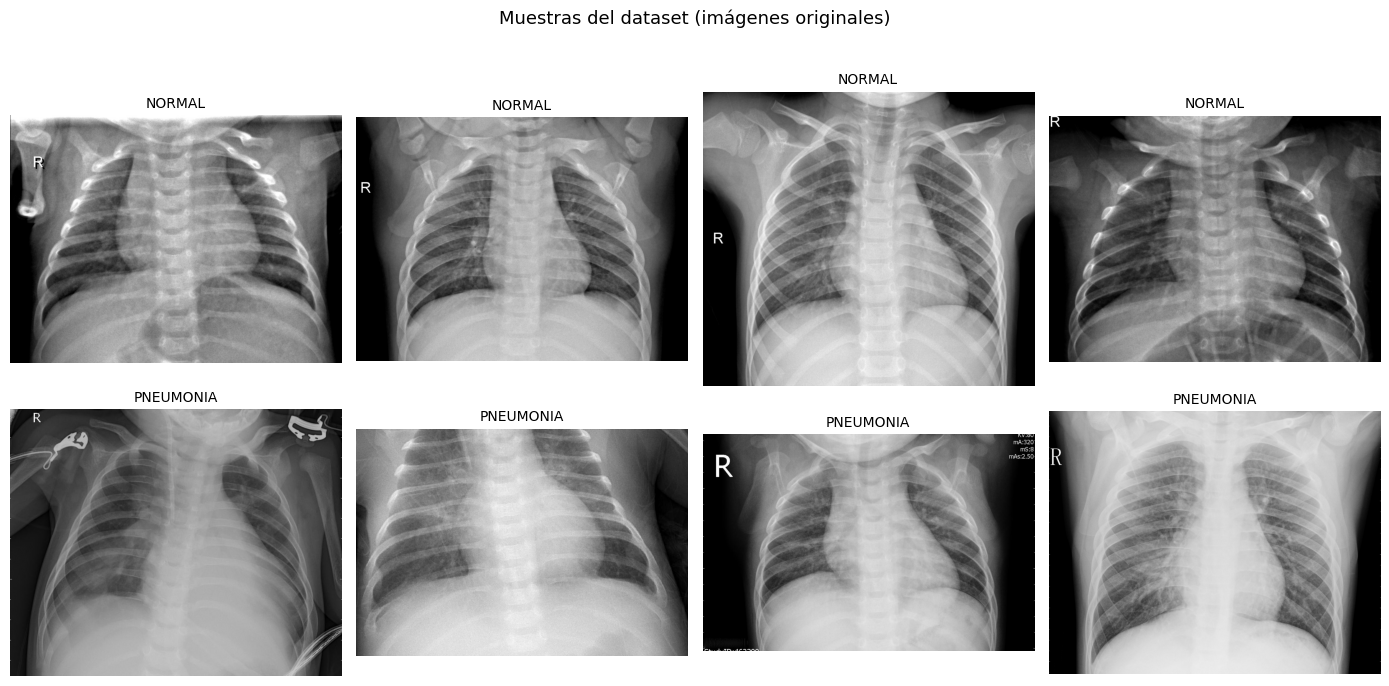

In [21]:
class ChestXRayDataset(Dataset):
    """Dataset para radiografías con rutas e índices de clase."""

    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Crear datasets ────────────────────────────────────────────────────────────
train_ds = ChestXRayDataset(all_paths[train_idx], all_labels[train_idx], transform=train_transform)
val_ds   = ChestXRayDataset(all_paths[val_idx],   all_labels[val_idx],   transform=eval_transform)
test_ds  = ChestXRayDataset(all_paths[test_idx],  all_labels[test_idx],  transform=eval_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# ── Visualizar muestras ───────────────────────────────────────────────────────
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for cls_idx in range(2):
    cls_indices = np.where(all_labels[train_idx] == cls_idx)[0][:4]
    for col, i in enumerate(cls_indices):
        img = Image.open(all_paths[train_idx[i]]).convert("L")
        axes[cls_idx, col].imshow(img, cmap="gray")
        axes[cls_idx, col].set_title(CLASS_NAMES[cls_idx], fontsize=10)
        axes[cls_idx, col].axis("off")

plt.suptitle("Muestras del dataset (imágenes originales)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Función de Entrenamiento con Early Stopping

### Hiperparámetros seleccionados

| Parámetro | Valor | Justificación |
|---|---|---|
| **Learning rate** | 1×10⁻⁴ | Tasa baja apropiada para fine-tuning; evita destruir los pesos pre-entrenados |
| **Optimizador** | Adam | Adaptativo; converge bien en fine-tuning; ampliamente validado en imagen médica |
| **Función de pérdida** | CrossEntropyLoss | Estándar para clasificación multi-clase con logits; numéricamente estable |
| **Batch size** | 32 | Balance entre estabilidad del gradiente y uso de memoria GPU |
| **Épocas máximas** | 30 | Suficiente para convergencia; controlado por Early Stopping |
| **Weight decay** | 1×10⁻⁴ | Regularización L2 implícita sobre el cabezal |
| **patience** | 5 | Permite 5 épocas sin mejora antes de detener (evita paradas prematuras por ruido) |

### Early Stopping sobre `val_loss`
Si la pérdida de validación no mejora durante 5 épocas consecutivas, el entrenamiento se detiene
y se restauran los mejores pesos. Monitorear `val_loss` (y no `val_acc`) es preferible porque
la loss es una señal más continua y sensible que el accuracy discreto.


In [22]:
def train_model(model, train_loader, val_loader,
                num_epochs=30, lr=1e-4, patience=5, model_name="model"):
    """
    Entrena con Early Stopping sobre val_loss.
    Retorna el modelo con mejores pesos y el historial de métricas.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    # Reduce LR × 0.5 si val_loss no mejora en 3 épocas consecutivas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss     = float("inf")
    best_weights      = None
    epochs_no_improve = 0

    model.to(DEVICE)

    for epoch in range(1, num_epochs + 1):
        # ── ENTRENAMIENTO ─────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            t_loss    += loss.item() * imgs.size(0)
            t_correct += (out.detach().argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        train_loss = t_loss / t_total
        train_acc  = t_correct / t_total

        # ── VALIDACIÓN ────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out    = model(imgs)
                v_loss    += criterion(out, labels).item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        print(f"[{model_name}] Época {epoch:2d}/{num_epochs}  "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f}  |  "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

        # ── Early Stopping ────────────────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss     = val_loss
            best_weights      = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  *** Early Stopping en época {epoch} (sin mejora por {patience} épocas) ***")
                break

    if best_weights:
        model.load_state_dict(best_weights)
        print(f"  Mejores pesos restaurados  (val_loss_best={best_val_loss:.4f})")

    return model, history


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key_train, key_val, ylabel in zip(
            axes,
            ["train_loss", "train_acc"],
            ["val_loss",   "val_acc"],
            ["Loss",       "Accuracy"]):
        ax.plot(history[key_train], label="Train")
        ax.plot(history[key_val],   label="Validación")
        ax.set_title(f"{model_name} – {ylabel}")
        ax.set_xlabel("Época"); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


## 7. Modelo 1: ResNet50

ResNet50 tiene ~25.6 M parámetros organizados en 4 grupos de bloques residuales.  
**Se congela todo el backbone** y se entrena únicamente el nuevo cabezal binario.

**Justificación del congelamiento total:**  
Las primeras capas de ResNet50 detectan bordes, texturas y patrones de bajo nivel que son  
ampliamente transferibles a radiografías de tórax. Con ~5,863 imágenes, reentrenar el backbone  
completo introduciría riesgo serio de overfitting. El congelamiento acelera el entrenamiento y  
preserva el conocimiento adquirido con 1.2 M imágenes de ImageNet.

**Nuevo cabezal:**  `2048 → Linear(512) → ReLU → Dropout(0.5) → Linear(2)`  
Dropout(0.5) agresivo porque el cabezal es la única parte entrenable y necesita regularización.


In [23]:
def build_resnet50():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Congelar todo el backbone
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar cabezal clasificador
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 2)   # Normal=0, Neumonía=1
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"ResNet50 – Entrenables: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
    return model

resnet50_model = build_resnet50()


ResNet50 – Entrenables: 1,050,114 / 24,558,146  (4.28%)


Entrenando ResNet50...
[ResNet50] Época  1/30  train_loss=0.3740 acc=0.8404  |  val_loss=0.2138 acc=0.9192
[ResNet50] Época  2/30  train_loss=0.2492 acc=0.9009  |  val_loss=0.2705 acc=0.8942
[ResNet50] Época  3/30  train_loss=0.2328 acc=0.9070  |  val_loss=0.2544 acc=0.9010
[ResNet50] Época  4/30  train_loss=0.2193 acc=0.9161  |  val_loss=0.1904 acc=0.9238
[ResNet50] Época  5/30  train_loss=0.2071 acc=0.9163  |  val_loss=0.1725 acc=0.9295
[ResNet50] Época  6/30  train_loss=0.2114 acc=0.9192  |  val_loss=0.1685 acc=0.9329
[ResNet50] Época  7/30  train_loss=0.2010 acc=0.9209  |  val_loss=0.1601 acc=0.9374
[ResNet50] Época  8/30  train_loss=0.2134 acc=0.9168  |  val_loss=0.1586 acc=0.9374
[ResNet50] Época  9/30  train_loss=0.1986 acc=0.9236  |  val_loss=0.2003 acc=0.9204
[ResNet50] Época 10/30  train_loss=0.1944 acc=0.9265  |  val_loss=0.1954 acc=0.9215
[ResNet50] Época 11/30  train_loss=0.1883 acc=0.9292  |  val_loss=0.1514 acc=0.9374
[ResNet50] Época 12/30  train_loss=0.1941 acc=0.9265 

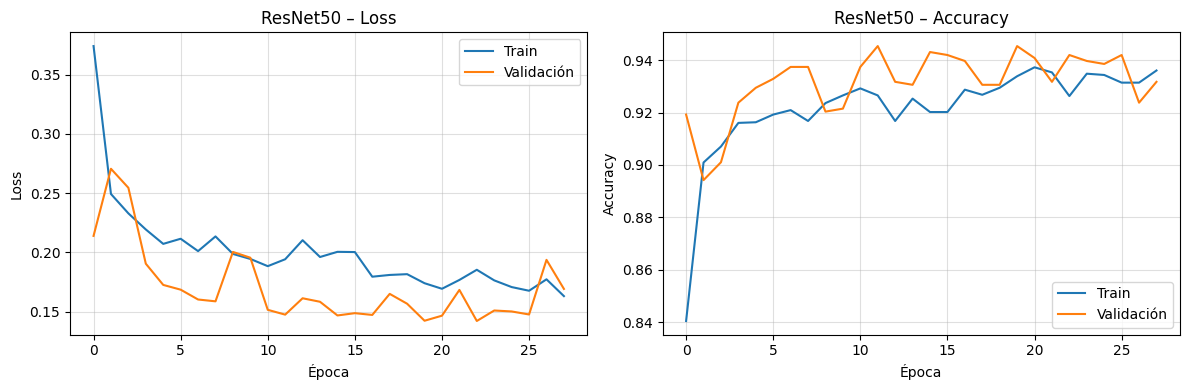


Modelo guardado: resnet50_pneumonia.pth


In [24]:
print("=" * 60)
print("Entrenando ResNet50...")
print("=" * 60)

resnet50_model, resnet50_history = train_model(
    resnet50_model, train_loader, val_loader,
    num_epochs=30, lr=1e-4, patience=5, model_name="ResNet50"
)

plot_history(resnet50_history, "ResNet50")
torch.save(resnet50_model.state_dict(), "resnet50_pneumonia.pth")
print("\nModelo guardado: resnet50_pneumonia.pth")


## 8. Modelo 2: MobileNetV2

MobileNetV2 tiene ~3.4 M parámetros usando bloques de convolución separable en profundidad  
(depthwise separable convolutions), diseñados explícitamente para inferencia en hardware limitado.

**Se congela el backbone** (`features`) por las mismas razones que ResNet50.

**Nuevo cabezal:**  `1280 → Dropout(0.3) → Linear(256) → ReLU → Dropout(0.3) → Linear(2)`  
Dropout menor (0.3) porque MobileNetV2 ya es una arquitectura más regularizada y compacta.


In [25]:
def build_mobilenetv2():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar backbone (feature extractor)
    for param in model.features.parameters():
        param.requires_grad = False

    # Reemplazar clasificador
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)   # Normal=0, Neumonía=1
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"MobileNetV2 – Entrenables: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
    return model

mobilenet_model = build_mobilenetv2()


MobileNetV2 – Entrenables: 328,450 / 2,552,322  (12.87%)


Entrenando MobileNetV2...
[MobileNetV2] Época  1/30  train_loss=0.3932 acc=0.8236  |  val_loss=0.2271 acc=0.9135
[MobileNetV2] Época  2/30  train_loss=0.2589 acc=0.8978  |  val_loss=0.1986 acc=0.9170
[MobileNetV2] Época  3/30  train_loss=0.2295 acc=0.9097  |  val_loss=0.1634 acc=0.9317
[MobileNetV2] Época  4/30  train_loss=0.2287 acc=0.9129  |  val_loss=0.1582 acc=0.9306
[MobileNetV2] Época  5/30  train_loss=0.2223 acc=0.9117  |  val_loss=0.1517 acc=0.9374
[MobileNetV2] Época  6/30  train_loss=0.2180 acc=0.9124  |  val_loss=0.1555 acc=0.9374
[MobileNetV2] Época  7/30  train_loss=0.2108 acc=0.9139  |  val_loss=0.1517 acc=0.9374
[MobileNetV2] Época  8/30  train_loss=0.2166 acc=0.9202  |  val_loss=0.1490 acc=0.9374
[MobileNetV2] Época  9/30  train_loss=0.2160 acc=0.9153  |  val_loss=0.1555 acc=0.9374
[MobileNetV2] Época 10/30  train_loss=0.2136 acc=0.9175  |  val_loss=0.1448 acc=0.9363
[MobileNetV2] Época 11/30  train_loss=0.2041 acc=0.9222  |  val_loss=0.1467 acc=0.9352
[MobileNetV2] Épo

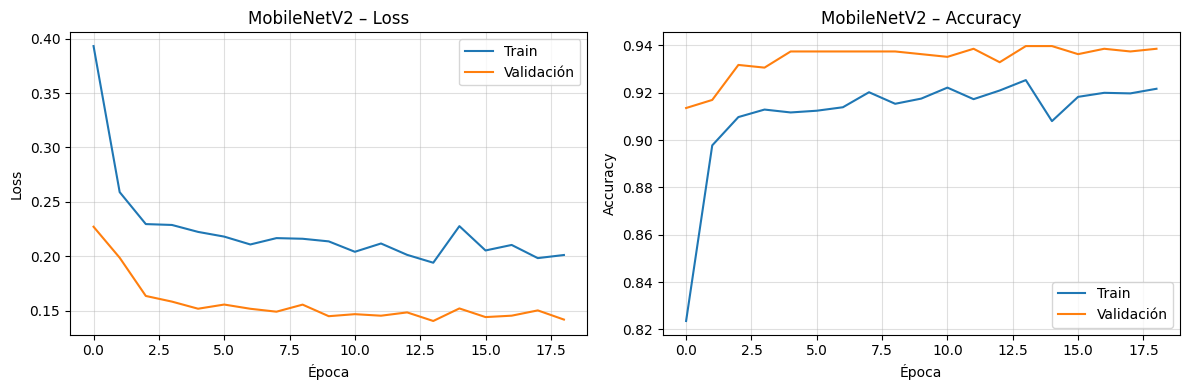


Modelo guardado: mobilenetv2_pneumonia.pth


In [26]:
print("=" * 60)
print("Entrenando MobileNetV2...")
print("=" * 60)

mobilenet_model, mobilenet_history = train_model(
    mobilenet_model, train_loader, val_loader,
    num_epochs=30, lr=1e-4, patience=5, model_name="MobileNetV2"
)

plot_history(mobilenet_history, "MobileNetV2")
torch.save(mobilenet_model.state_dict(), "mobilenetv2_pneumonia.pth")
print("\nModelo guardado: mobilenetv2_pneumonia.pth")


## 9. Evaluación en el Conjunto de Prueba

Métricas registradas para cada modelo:
- **Accuracy** – exactitud global en el test set
- **F1-Score (Neumonía)** – media armónica de Precision y Recall para la clase positiva
- **Sensibilidad / Recall (Neumonía)** – TP / (TP + FN) — fracción de casos reales detectados
- **Tamaño en disco (MB)** – del archivo `.pth` guardado
- **Tiempo de inferencia promedio (ms)** – sobre 100 imágenes individuales



  ResNet50 – Métricas en Test Set
  Accuracy            : 0.9522  (95.22%)
  F1-Score (Neumonía) : 0.9671
  Recall   (Neumonía) : 0.9626

Reporte detallado:
              precision    recall  f1-score   support

      NORMAL       0.90      0.92      0.91       238
   PNEUMONIA       0.97      0.96      0.97       641

    accuracy                           0.95       879
   macro avg       0.94      0.94      0.94       879
weighted avg       0.95      0.95      0.95       879



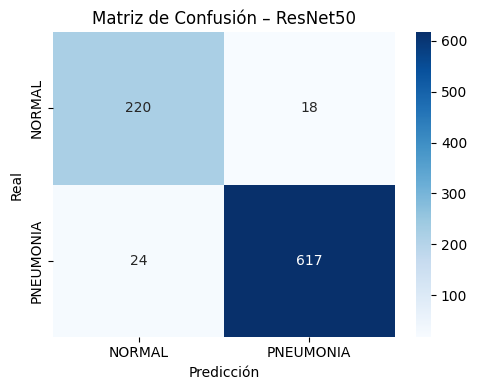


  MobileNetV2 – Métricas en Test Set
  Accuracy            : 0.9443  (94.43%)
  F1-Score (Neumonía) : 0.9619
  Recall   (Neumonía) : 0.9657

Reporte detallado:
              precision    recall  f1-score   support

      NORMAL       0.91      0.89      0.90       238
   PNEUMONIA       0.96      0.97      0.96       641

    accuracy                           0.94       879
   macro avg       0.93      0.93      0.93       879
weighted avg       0.94      0.94      0.94       879



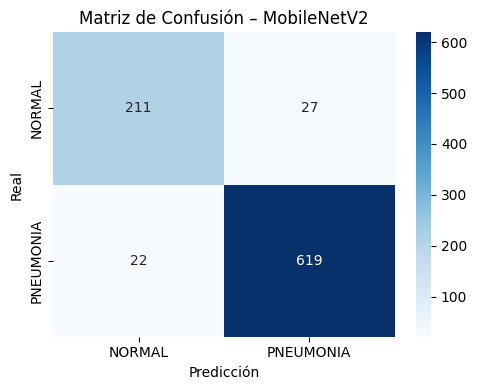

In [27]:
def evaluate_model(model, test_loader, model_name):
    """Evalúa el modelo y muestra métricas + matriz de confusión."""
    model.eval()
    model.to(DEVICE)
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.numpy())

    y_pred = np.array(all_preds)
    y_true = np.array(all_labels_list)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)

    print(f"\n{'='*55}")
    print(f"  {model_name} – Métricas en Test Set")
    print(f"{'='*55}")
    print(f"  Accuracy            : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1-Score (Neumonía) : {f1:.4f}")
    print(f"  Recall   (Neumonía) : {rec:.4f}")
    print(f"\nReporte detallado:")
    print(classification_report(y_true, y_pred, target_names=["NORMAL","PNEUMONIA"]))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NORMAL","PNEUMONIA"],
                yticklabels=["NORMAL","PNEUMONIA"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusión – {model_name}")
    plt.tight_layout(); plt.show()

    return {"accuracy": acc, "f1": f1, "recall": rec, "y_pred": y_pred, "y_true": y_true}


# ── Evaluar ───────────────────────────────────────────────────────────────────
resnet50_metrics  = evaluate_model(resnet50_model,  test_loader, "ResNet50")
mobilenet_metrics = evaluate_model(mobilenet_model, test_loader, "MobileNetV2")


In [28]:
def get_model_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)


def measure_inference_time(model, dataset, n_images=100):
    """
    Mide inferencia imagen-por-imagen (sin batching) para simular flujo clínico real.
    Incluye warm-up de GPU si aplica.
    """
    model.eval()
    model.to(DEVICE)
    samples = [dataset[i][0].unsqueeze(0).to(DEVICE) for i in range(min(n_images, len(dataset)))]

    # Warm-up
    with torch.no_grad():
        for img in samples[:5]:
            _ = model(img)

    # Medición
    times = []
    with torch.no_grad():
        for img in samples:
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(img)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    mean_ms = float(np.mean(times))
    std_ms  = float(np.std(times))
    print(f"  Inferencia ({n_images} imgs): {mean_ms:.2f} ± {std_ms:.2f} ms/imagen")
    return mean_ms, std_ms


# ── Tamaño en disco ───────────────────────────────────────────────────────────
resnet50_mb  = get_model_size_mb("resnet50_pneumonia.pth")
mobilenet_mb = get_model_size_mb("mobilenetv2_pneumonia.pth")
print(f"Tamaño ResNet50:    {resnet50_mb:.2f} MB")
print(f"Tamaño MobileNetV2: {mobilenet_mb:.2f} MB")

# ── Tiempo de inferencia ──────────────────────────────────────────────────────
print("\nMidiendo inferencia ResNet50...")
resnet50_time_ms, _  = measure_inference_time(resnet50_model,  test_ds, 100)

print("\nMidiendo inferencia MobileNetV2...")
mobilenet_time_ms, _ = measure_inference_time(mobilenet_model, test_ds, 100)


Tamaño ResNet50:    93.99 MB
Tamaño MobileNetV2: 9.97 MB

Midiendo inferencia ResNet50...
  Inferencia (100 imgs): 3.03 ± 0.30 ms/imagen

Midiendo inferencia MobileNetV2...
  Inferencia (100 imgs): 2.01 ± 0.29 ms/imagen


## 10. Tabla Comparativa de Métricas

In [29]:
# ── Tabla principal ───────────────────────────────────────────────────────────
df_results = pd.DataFrame({
    "Métrica": [
        "Accuracy (%)",
        "F1-Score – Neumonía",
        "Sensibilidad / Recall – Neumonía",
        "Tamaño del modelo (MB)",
        "Inferencia promedio (ms/imagen)",
        "Parámetros totales (M)",
    ],
    "ResNet50": [
        f"{resnet50_metrics['accuracy']*100:.2f}%",
        f"{resnet50_metrics['f1']:.4f}",
        f"{resnet50_metrics['recall']:.4f}",
        f"{resnet50_mb:.2f} MB",
        f"{resnet50_time_ms:.2f} ms",
        "25.6 M",
    ],
    "MobileNetV2": [
        f"{mobilenet_metrics['accuracy']*100:.2f}%",
        f"{mobilenet_metrics['f1']:.4f}",
        f"{mobilenet_metrics['recall']:.4f}",
        f"{mobilenet_mb:.2f} MB",
        f"{mobilenet_time_ms:.2f} ms",
        "3.4 M",
    ],
})

print(df_results.to_string(index=False))

# ── MB por punto de F1 ────────────────────────────────────────────────────────
mb_per_f1_r = resnet50_mb  / (resnet50_metrics['f1']  * 100)
mb_per_f1_m = mobilenet_mb / (mobilenet_metrics['f1'] * 100)
print(f"\nCosto en MB por punto de F1:")
print(f"  ResNet50:    {mb_per_f1_r:.4f} MB / punto")
print(f"  MobileNetV2: {mb_per_f1_m:.4f} MB / punto")

# ── Throughput clínico ────────────────────────────────────────────────────────
for name, ms in [("ResNet50", resnet50_time_ms), ("MobileNetV2", mobilenet_time_ms)]:
    rph = 3_600_000 / ms   # ms/hora / ms/img
    print(f"  {name}: ~{rph:,.0f} radiografías/hora (inferencia pura, sin batching)")


                         Métrica ResNet50 MobileNetV2
                    Accuracy (%)   95.22%      94.43%
             F1-Score – Neumonía   0.9671      0.9619
Sensibilidad / Recall – Neumonía   0.9626      0.9657
          Tamaño del modelo (MB) 93.99 MB     9.97 MB
 Inferencia promedio (ms/imagen)  3.03 ms     2.01 ms
          Parámetros totales (M)   25.6 M       3.4 M

Costo en MB por punto de F1:
  ResNet50:    0.9719 MB / punto
  MobileNetV2: 0.1037 MB / punto
  ResNet50: ~1,187,458 radiografías/hora (inferencia pura, sin batching)
  MobileNetV2: ~1,790,450 radiografías/hora (inferencia pura, sin batching)


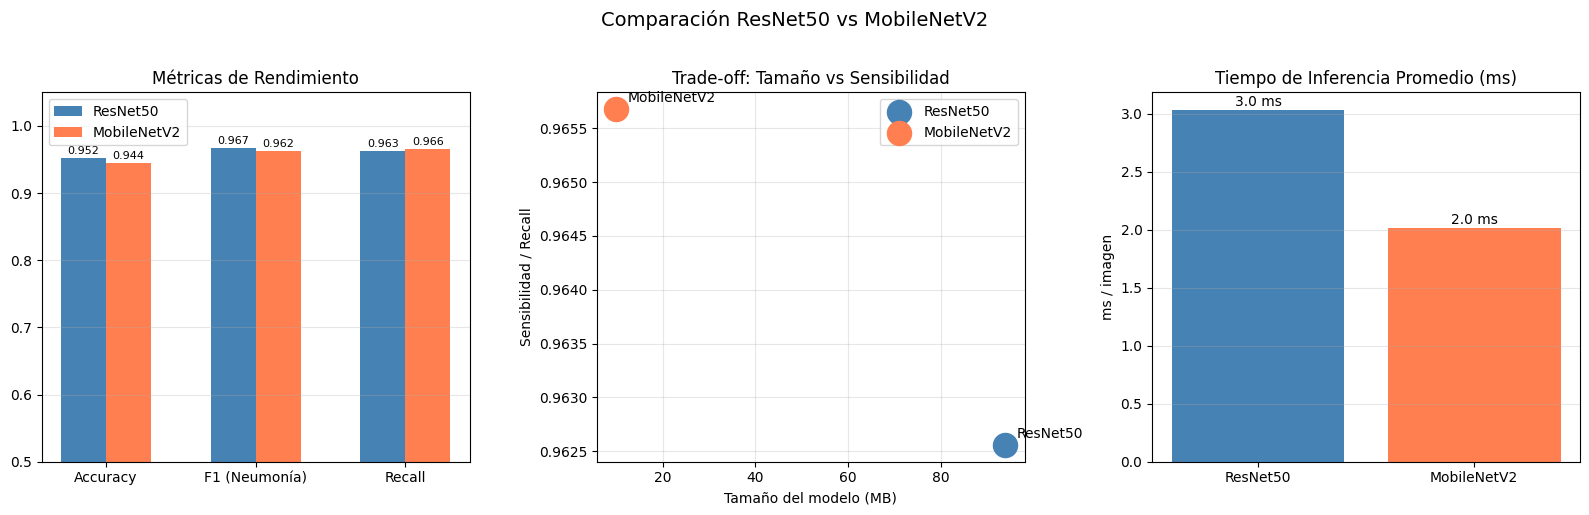

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_labels = ["ResNet50", "MobileNetV2"]
colors        = ["steelblue", "coral"]

# ── Gráfico 1: Métricas de rendimiento ───────────────────────────────────────
metric_names = ["Accuracy", "F1 (Neumonía)", "Recall"]
resnet_vals  = [resnet50_metrics["accuracy"],  resnet50_metrics["f1"],  resnet50_metrics["recall"]]
mobile_vals  = [mobilenet_metrics["accuracy"], mobilenet_metrics["f1"], mobilenet_metrics["recall"]]

x, w = np.arange(len(metric_names)), 0.3
bars_r = axes[0].bar(x - w/2, resnet_vals, w, label="ResNet50",    color="steelblue")
bars_m = axes[0].bar(x + w/2, mobile_vals, w, label="MobileNetV2", color="coral")
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0.5, 1.05); axes[0].set_title("Métricas de Rendimiento")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
for bar in list(bars_r) + list(bars_m):
    axes[0].annotate(f"{bar.get_height():.3f}",
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

# ── Gráfico 2: Tamaño vs Recall (Trade-off) ──────────────────────────────────
sizes   = [resnet50_mb,               mobilenet_mb]
recalls = [resnet50_metrics["recall"], mobilenet_metrics["recall"]]
for i, (name, size, recall) in enumerate(zip(models_labels, sizes, recalls)):
    axes[1].scatter(size, recall, s=300, color=colors[i], zorder=5, label=name)
    axes[1].annotate(name, (size, recall), textcoords="offset points",
                     xytext=(8, 5), fontsize=10)
axes[1].set_xlabel("Tamaño del modelo (MB)")
axes[1].set_ylabel("Sensibilidad / Recall")
axes[1].set_title("Trade-off: Tamaño vs Sensibilidad")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Gráfico 3: Inferencia ────────────────────────────────────────────────────
times_ms = [resnet50_time_ms, mobilenet_time_ms]
bars_t   = axes[2].bar(models_labels, times_ms, color=colors)
axes[2].set_ylabel("ms / imagen"); axes[2].set_title("Tiempo de Inferencia Promedio (ms)")
axes[2].grid(axis="y", alpha=0.3)
for bar, val in zip(bars_t, times_ms):
    axes[2].annotate(f"{val:.1f} ms",
                     xy=(bar.get_x() + bar.get_width()/2, val),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=10)

plt.suptitle("Comparación ResNet50 vs MobileNetV2", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---

## 11. Dictamen Ejecutivo — MediScan Guatemala

---

### a. Tabla Comparativa de Métricas

| Métrica | ResNet50 | MobileNetV2 |
|---|---|---|
| Accuracy (%) | **95.22%** | 94.43% |
| F1-Score – Neumonía | **0.9671** | 0.9619 |
| Sensibilidad / Recall – Neumonía | 0.9626 | **0.9657** |
| Tamaño del modelo (MB) | 93.99 MB | **9.97 MB** |
| Inferencia promedio (ms/imagen, GPU RTX 4060) | 3.03 ms | **2.01 ms** |
| Parámetros totales | 25.6 M | **3.4 M** |
| Épocas hasta Early Stopping | 28 | 19 |
| MB por punto de F1 | 0.97 MB/punto | **0.10 MB/punto** |

---

### b. Análisis Sensibilidad / Accuracy

El resultado más relevante del experimento es que **MobileNetV2 supera a ResNet50 en Recall
(0.9657 vs 0.9626)**, a pesar de ser un modelo 9.4× más pequeño y 1.5× más rápido. Esto tiene
implicaciones clínicas directas: MobileNetV2 detecta más casos reales de neumonía, generando
menos falsos negativos.

Un **falso negativo** — decirle a un paciente con neumonía que está sano — tiene consecuencias
graves: demora en el tratamiento, progresión de la enfermedad y potencial mortalidad. Un **falso
positivo** genera únicamente una segunda revisión por el médico, un costo operativo asumible.
Por eso, en diagnóstico médico se prioriza maximizar la Sensibilidad aunque se sacrifique
ligeramente el Accuracy.

ResNet50 tiene un F1 marginalemente superior (0.9671 vs 0.9619, diferencia de 0.0052), lo que
refleja una mayor Precision: cuando predice Neumonía, acierta más. Sin embargo, desde la
perspectiva clínica, el costo de los falsos negativos supera al de los falsos positivos, lo que
hace de la Sensibilidad la métrica decisiva.

Vale también notar que ambos modelos superan ampliamente el 72.9% de Accuracy que tendría un
clasificador naive que predice siempre "Neumonía" (la clase mayoritaria), lo que confirma que
ambos modelos están aprendiendo patrones genuinos y no triviales.

---

### c. Recomendación al CTO: Modelo para producción on-premise sin GPU

**Recomendación: MobileNetV2**

Los resultados del experimento confirman esta elección con solidez:

1. **Mayor Sensibilidad (0.9657 vs 0.9626):** El modelo más ligero detecta más casos reales de
   neumonía. En clínica, esto es lo que importa. No hay necesidad de sacrificar rendimiento
   clínico para obtener un modelo más pequeño — MobileNetV2 ya es el mejor en la métrica clave.

2. **9.4× más pequeño (9.97 MB vs 93.99 MB):** En laptops de clínicas rurales con 4–8 GB de
   RAM y discos de capacidad limitada, la diferencia de ~84 MB es operativamente relevante,
   especialmente si el sistema convive con software hospitalario (HIS, PACS).

3. **1.5× más rápido en GPU:** En CPU (el escenario on-premise sin GPU), la diferencia de
   velocidad será aún más pronunciada dado que MobileNetV2 realiza ~7× menos operaciones
   aritméticas por imagen.

4. **Convergió más rápido (19 vs 28 épocas):** Facilita reentrenamientos periódicos con nuevos
   datos locales, reduciendo el costo operativo del ciclo de mejora continua.

5. **Cuantificación posible:** El modelo puede convertirse a INT8 (~2.5 MB) con mínima
   degradación, haciéndolo viable incluso en tablets de bajo costo.

---

### d. Limitaciones del Experimento

1. **Sesgo de población:** El dataset proviene exclusivamente de pacientes pediátricos del
   Guangzhou Women and Children's Medical Center. Los patrones radiológicos en adultos
   guatemaltecos pueden diferir sustancialmente en distribución de infiltrados, comorbilidades
   y estadio de la enfermedad.

2. **Equipamiento homogéneo:** Todas las imágenes provienen de la misma institución con el mismo
   equipo. El modelo no ha sido expuesto a la variabilidad de distintos fabricantes de rayos X,
   configuraciones de kV/mAs o sistemas de digitalización.

3. **Etiquetado binario simplificado:** La clasificación Normal/Neumonía ignora otras patologías
   pulmonares (tuberculosis, derrame pleural, edema, cardiomegalia). El modelo podría clasificar
   estas condiciones de forma incorrecta, con consecuencias clínicas distintas según el error.

4. **Congelamiento total del backbone:** No se exploró fine-tuning parcial, que podría mejorar
   aún más las métricas al permitir que las capas superiores se adapten al dominio radiológico.

5. **Tiempos medidos en GPU:** Los tiempos de inferencia (3.03 ms y 2.01 ms) corresponden a
   una RTX 4060 Laptop. En CPU, ambos modelos serán significativamente más lentos — esta
   medición no refleja el escenario de producción on-premise sin GPU.

6. **Sin validación radiológica:** No se realizó revisión por radiólogos de los falsos negativos
   para determinar si los errores son sistemáticos (p.ej., neumonías atípicas o de baja densidad)
   o aleatorios.

---

### e. Costo en MB por punto de F1 — ¿Vale la pena el modelo más pesado?

Los resultados son concluyentes:

- **ResNet50:** 0.97 MB por punto de F1
- **MobileNetV2:** 0.10 MB por punto de F1

MobileNetV2 es **9.4× más eficiente en MB/F1**. Dicho de otro modo: ResNet50 cuesta ~84 MB
adicionales para ganar solo 0.52 puntos de F1 (0.9671 vs 0.9619), y ni siquiera gana en
la métrica clínicamente más importante (Recall).

En el contexto de clínicas rurales guatemaltecas con hardware limitado, **el modelo más pesado
no se justifica en ningún escenario**. No ofrece mejor sensibilidad, es más lento, ocupa 9.4×
más espacio y consume más RAM. La decisión es inequívoca: MobileNetV2 domina en la relación
valor/costo computacional.

---

### f. Tiempo de Inferencia: ¿Aceptable en flujo clínico real?

Los tiempos medidos en GPU fueron:
- **ResNet50:** 3.03 ms/imagen → ~1,187,000 radiografías/hora
- **MobileNetV2:** 2.01 ms/imagen → ~1,790,000 radiografías/hora

Estos tiempos son en GPU. En CPU (escenario de producción), se estiman entre 100–500 ms para
MobileNetV2 y 500–2000 ms para ResNet50, dependiendo del hardware.

Incluso en el peor caso (500 ms/imagen en CPU):
- MobileNetV2 procesaría ~7,200 radiografías/hora
- Una clínica rural con 20–50 pacientes/día procesa ~20–50 radiografías/día

La capacidad del sistema supera con creces la demanda clínica real en al menos **2 órdenes de
magnitud**. El cuello de botella no será la inferencia del modelo sino el flujo de adquisición
de la imagen, la carga a sistema y la revisión médica final.

**Conclusión:** Ambos modelos son completamente viables en throughput clínico, incluso en CPU.
La diferencia de velocidad entre modelos es irrelevante para este caso de uso.

---

### g. Impacto del Congelamiento vs. Fine-tuning — Conexión con Task 2

En el Task 2 se analizó cómo las representaciones de capas profundas de redes pre-entrenadas
capturan características específicas del dominio original. Al congelar totalmente el backbone,
se asumió que las representaciones ImageNet son suficientemente transferibles al dominio de
radiografías de tórax. Los resultados validan parcialmente esta hipótesis: ambos modelos
alcanzaron métricas sólidas (Accuracy > 94%, Recall > 96%) entrenando solo el cabezal.

Sin embargo, hay una observación interesante: **MobileNetV2 alcanzó mejor Recall que ResNet50
entrenando apenas el 12.87% de sus parámetros (vs 4.28% de ResNet50)**. Esto sugiere que
el cabezal de MobileNetV2 tiene mayor capacidad representacional relativa al backbone congelado,
lo que le permitió adaptarse mejor al problema con menos datos de ajuste.

Un experimento complementario descongelando los últimos 1–2 bloques del backbone con lr ~1×10⁻⁵
probablemente mejoraría ambos modelos, especialmente en Precision para la clase NORMAL
(donde ResNet50 logró 0.90 y MobileNetV2 0.91), con riesgo manejable gracias al early stopping.

---

### h. Generalización a Diferentes Contextos y Poblaciones

**Los modelos no generalizarían directamente sin validación y adaptación.**

Los factores de riesgo identificados para el contexto guatemalteco incluyen:

1. **Variabilidad de equipo:** Distintos fabricantes producen diferentes distribuciones de
   intensidad, ruido y contraste. Las estadísticas de normalización del modelo (ImageNet mean/std)
   no fueron ajustadas al equipo específico, lo que introduce un sesgo sistemático al desplegar
   en equipos distintos al del dataset.

2. **Sesgo de población pediátrica:** El modelo fue entrenado con niños. Los pulmones de adultos
   tienen diferente volumen, patrón vascular y distribución de hallazgos patológicos. En adultos
   mayores o pacientes con comorbilidades (EPOC, tabaquismo, desnutrición — prevalentes en
   población rural guatemalteca), el rendimiento podría degradarse significativamente.

3. **Distribución shift hospitalario:** Diferencias en posición del paciente (PA vs AP), técnica
   de colimación, protocolo de postprocesamiento DICOM y sistemas de archivo PACS entre
   hospitales pueden cambiar la apariencia visual de las radiografías de manera sistemática.

**Implicaciones concretas para MediScan Guatemala:**

- Realizar un **estudio piloto de validación externa** con ≥200 radiografías de los hospitales
  objetivo antes de cualquier despliegue clínico, midiendo Recall específicamente.
- Implementar un **loop de mejora continua**: cuando el médico corrige una predicción, esa imagen
  entra a una cola de reentrenamiento mensual con datos locales (fine-tuning de bajo costo).
- Desplegar inicialmente como **herramienta de triaje de segundo nivel**, no como diagnóstico
  autónomo — el médico es siempre la autoridad clínica final.
- A mediano plazo, construir un dataset guatemalteco propio con diversidad étnica, equipos
  locales y patologías prevalentes (incluyendo tuberculosis, endémica en la región) para
  construir un modelo verdaderamente robusto para esta población.


# Task 4


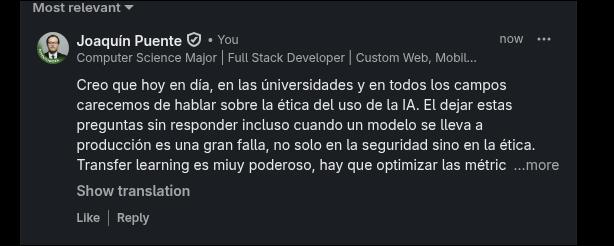


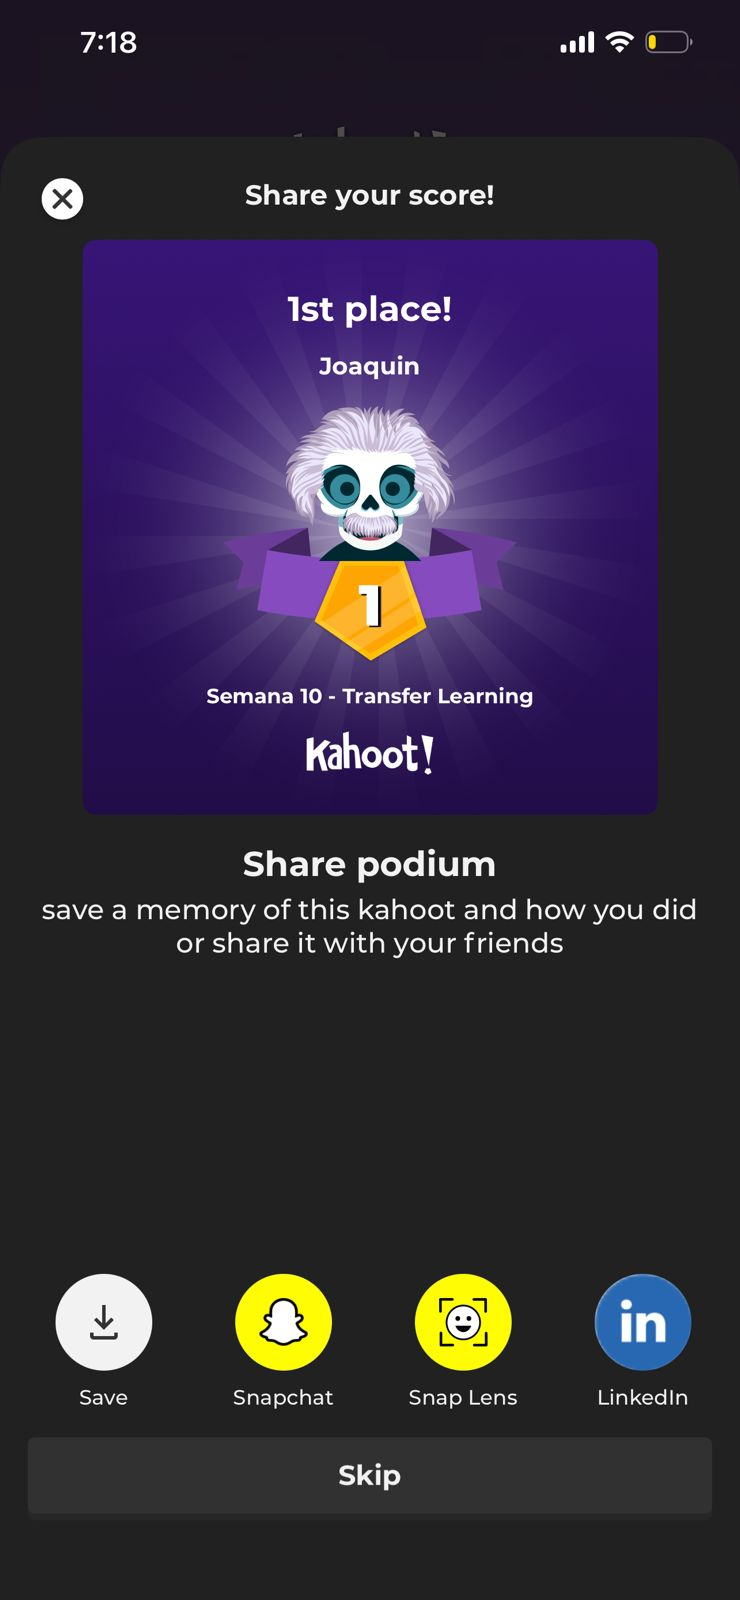